In [2]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Extracting ZIP
import zipfile
zip_path = "/content/drive/My Drive/Mall Customer Dataset.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset/")

***TASK 1: Data Loading and Data Understanding***

In [1]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import IsolationForest

In [5]:
# Step 2: Load Dataset
df = pd.read_csv('/content/dataset/Mall_Customers.csv')
# Display First 5 Rows
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [6]:
# Step 3: Check Dataset Structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [7]:
# Step 4: Check Dataset Shape
print('Rows and Columns:', df.shape)

Rows and Columns: (200, 5)


In [8]:
# Step 5: Identify Columns and Data Types
print(df.dtypes)

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [9]:
# Step 6: Understand Dataset Features
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [10]:
# Step 7: Dataset Description
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


***TASK 2: Data Cleaning and Preprocessing***

In [11]:
# Step 8: Check Missing Values
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [12]:
# Step 9: Handle Missing Values
# Fill numerical missing values with mean
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [13]:
# Step 10: Check Duplicate Values
print('Duplicate Rows:', df.duplicated().sum())

Duplicate Rows: 0


In [14]:
# Step 11: Remove Duplicate Values
df = df.drop_duplicates()
print('Dataset Shape After Removing Duplicates:', df.shape)

Dataset Shape After Removing Duplicates: (200, 5)


In [15]:
# Step 12: Check Data Labeling
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [16]:
# Step 13: Convert Dataset into Labeled Data

# Create Customer Category Label

df['Customer_Category'] = np.where(
    df['Spending Score (1-100)'] >= 50,
    'High Spender',
    'Low Spender'
)

print(df[['Spending Score (1-100)', 'Customer_Category']].head())

   Spending Score (1-100) Customer_Category
0                      39       Low Spender
1                      81      High Spender
2                       6       Low Spender
3                      77      High Spender
4                      40       Low Spender


In [17]:
# Step 14: Encode Categorical Data
encoder = LabelEncoder()
# Encode Gender
df['Gender'] = encoder.fit_transform(df['Gender'])
# Encode Customer Category
df['Customer_Category'] = encoder.fit_transform(df['Customer_Category'])
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   Customer_Category  
0                  1  
1                  0  
2                  1  
3                  0  
4                  1  


***TASK 3: Exploratory Data Analysis***

In [18]:
# Step 15: Check Class Balance
print(df['Customer_Category'].value_counts())

Customer_Category
0    102
1     98
Name: count, dtype: int64


***TASK 4: Data Visualization***

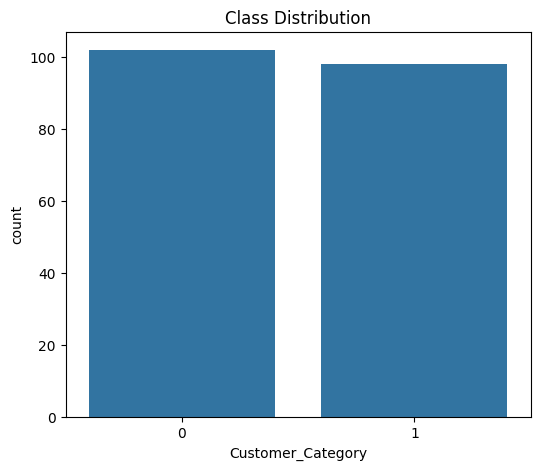

In [19]:
# Step 16: Visualize Class Distribution
plt.figure(figsize=(6,5))
sns.countplot(x=df['Customer_Category'])
plt.title('Class Distribution')
plt.show()

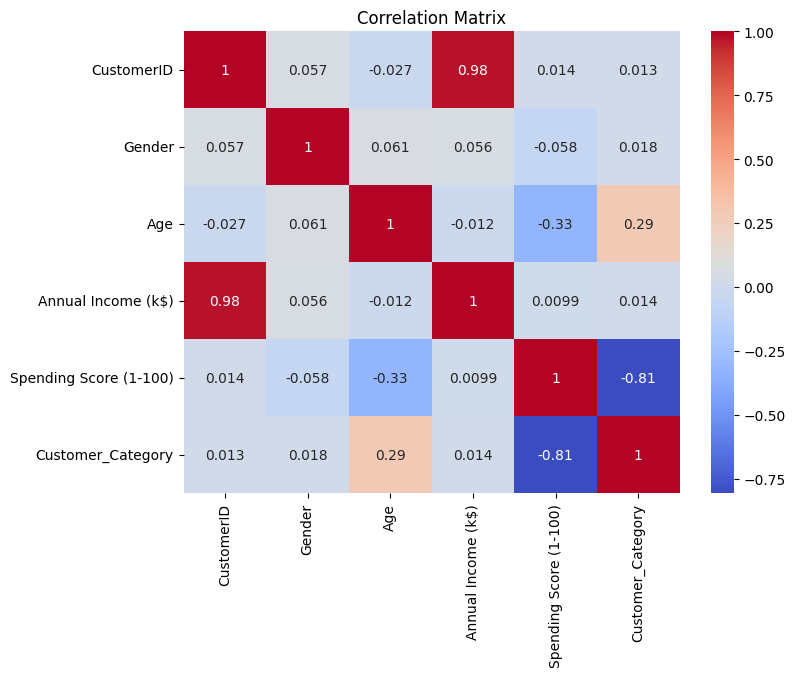

In [20]:
# Step 17: Correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

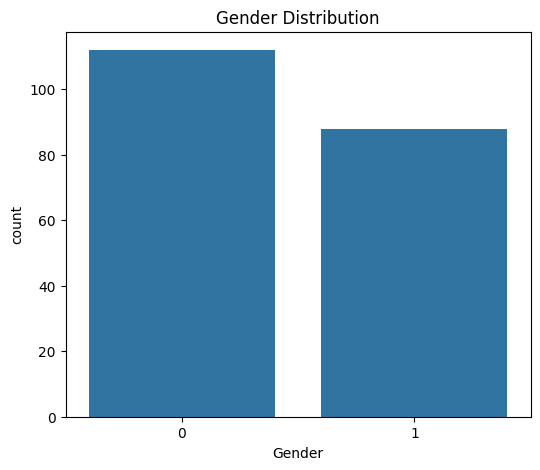

In [21]:
# Step 18: Gender Distribution
plt.figure(figsize=(6,5))
sns.countplot(x=df['Gender'])
plt.title('Gender Distribution')
plt.show()

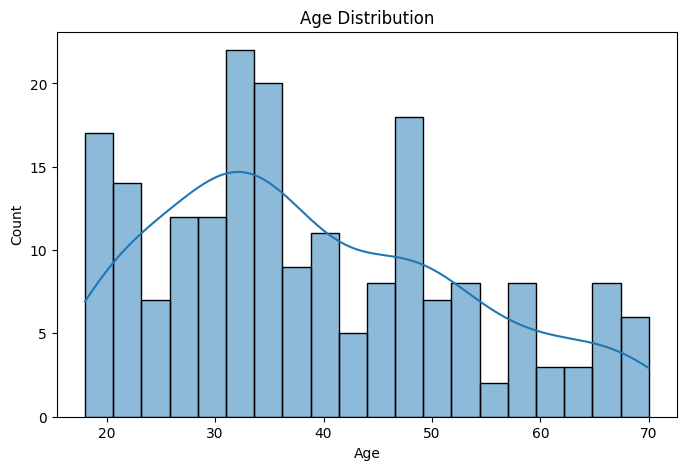

In [22]:
# Step 19: Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

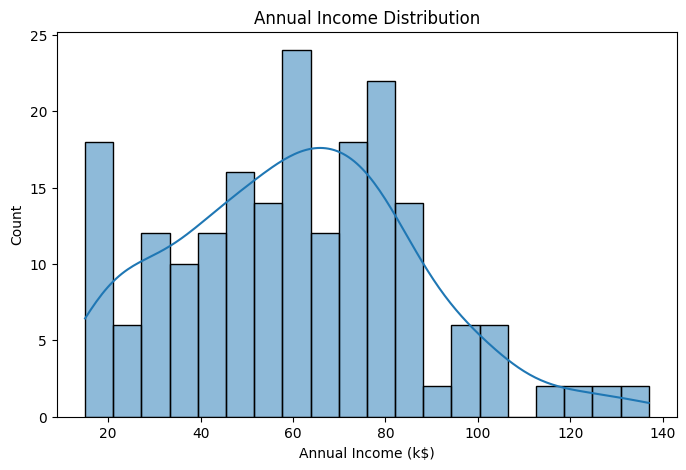

In [23]:
# Step 20: Annual Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title('Annual Income Distribution')
plt.show()

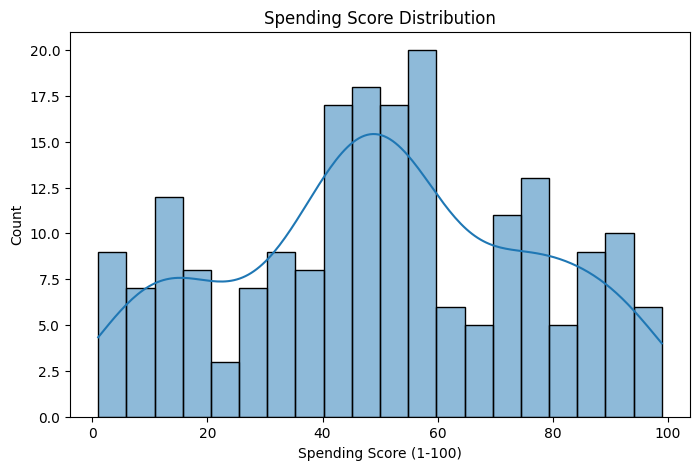

In [24]:
# Step 21: Spending Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title('Spending Score Distribution')
plt.show()

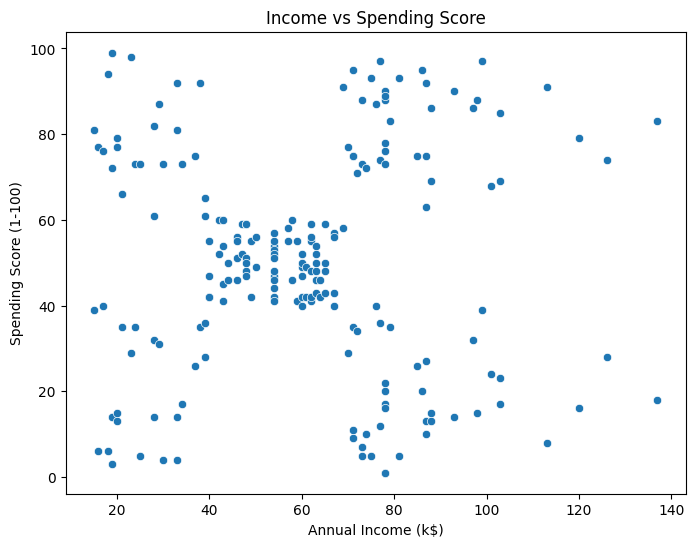

In [25]:
# Step 22: Income vs Spending Score
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)']
)
plt.title('Income vs Spending Score')
plt.show()

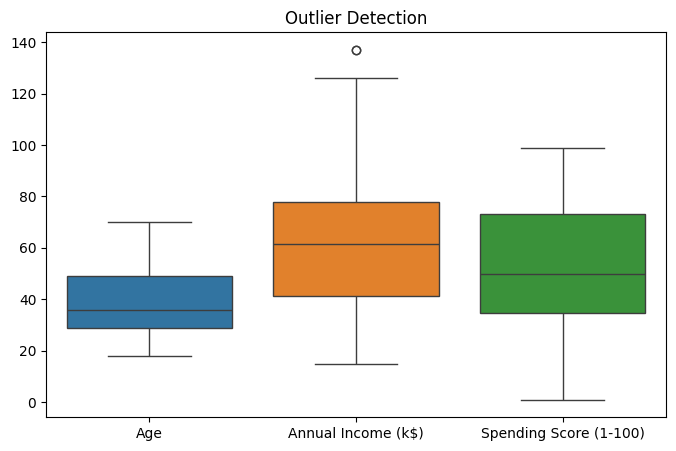

In [26]:
# Step 23: Boxplot for Outlier Detection
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.title('Outlier Detection')
plt.show()

***TASK 5: Predictive Model or Insight Project***

In [27]:
# Step 24: Feature Selection
X = df[['Gender', 'Age', 'Annual Income (k$)']]
y = df['Spending Score (1-100)']

In [28]:
# Step 25: Train Test Split for Regression
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
# Step 26: Train Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [33]:
# Step 27: Regression Prediction
predictions = lr.predict(X_test)
print(predictions[:10])

[59.82812944 58.84945709 37.0469889  54.91842692 39.84329514 64.23552817
 55.67685009 51.87565203 46.07289703 59.89547225]


In [34]:
# Step 28: Regression Evaluation
mse = mean_squared_error(y_test, predictions)
print('Mean Squared Error:', mse)

Mean Squared Error: 480.673141707248


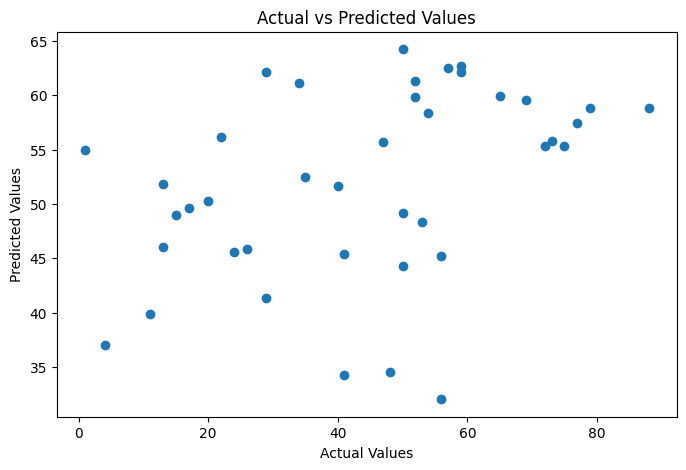

In [35]:
# Step 29: Regression Visualization
plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [36]:
# Step 30: Prepare Data for Classification
X = df[['Gender', 'Age', 'Annual Income (k$)']]
y = df['Customer_Category']

In [37]:
# Step 31: Train Test Split for Classification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
# Step 32: Train Classification Model
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

In [39]:
# Step 33: Classification Prediction
class_predictions = classifier.predict(X_test)
print(class_predictions[:10])

[0 0 1 0 1 0 0 0 1 0]


In [41]:
# Step 34: Classification Accuracy
accuracy = accuracy_score(y_test, class_predictions)
print('Accuracy:', accuracy*100)

Accuracy: 67.5


In [42]:
# Step 35: Classification Report
print(classification_report(y_test, class_predictions))

              precision    recall  f1-score   support

           0       0.65      0.75      0.70        20
           1       0.71      0.60      0.65        20

    accuracy                           0.68        40
   macro avg       0.68      0.68      0.67        40
weighted avg       0.68      0.68      0.67        40



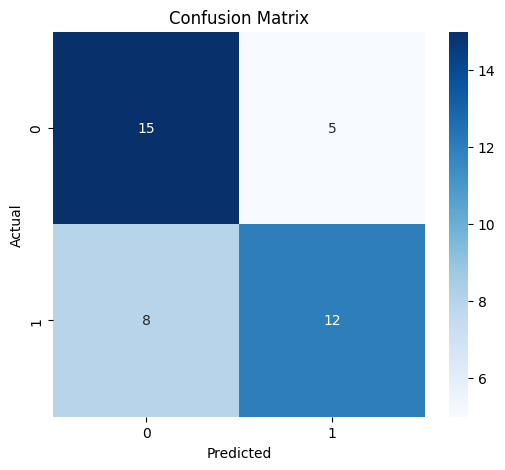

In [43]:
# Step 36: Confusion Matrix
cm = confusion_matrix(y_test, class_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [44]:
# Step 37: Predict New Customer Spending Behavior
# Example:
# Gender = 1
# Age = 30
# Annual Income = 70

sample = [[1, 30, 70]]
prediction = classifier.predict(sample)
print('Predicted Class:', prediction)

Predicted Class: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [53]:
# Step 38: Key Insights
print('Key Insights:')
print('1. Customers with higher income often have higher spending scores.')
print('2. Spending behavior varies across age groups.')
print('3. Dataset is mostly balanced after preprocessing.')
print('4. Outliers were removed successfully.')
print('5. Machine learning models successfully predicted customer behavior.\n')

# Data Insight Based Recommendations

print('Recommendations:')
print('1. Target high spending customers with premium offers.')
print('2. Use age-based marketing strategies.')
print('3. Improve engagement with low spending customers.')
print('4. Focus marketing on customers with higher annual income.')

Key Insights:
1. Customers with higher income often have higher spending scores.
2. Spending behavior varies across age groups.
3. Dataset is mostly balanced after preprocessing.
4. Outliers were removed successfully.
5. Machine learning models successfully predicted customer behavior.

Recommendations:
1. Target high spending customers with premium offers.
2. Use age-based marketing strategies.
3. Improve engagement with low spending customers.
4. Focus marketing on customers with higher annual income.
